In [1]:
'''
Let's import useful and "standard" packages.
Not all packages will be used in the short course. It is my habit to import them
ahead of time.
'''

import numpy as np # numpy is a powerful package for numeric calculation, we rename it as "np"
import sys, os # these are system related packages
import pickle # pickle is a cute package to save and load your custom data
import shutil # for high-level file operations
import scipy, sklearn, skimage, math # these are useful packages for scientific computing, machine learning, image processing, and math calculation
import matplotlib.pyplot as plt # this is a powerful package for visualization, e.g., curves, bar charts, histograms, and various visualizations.
import cv2 # this is a powerful package for computer vision
from pathlib import Path
from PIL import Image
from sklearn.metrics import confusion_matrix

In [2]:
'''
Let's import the famous PyTorch package, supporting deep learning.
It is convenient to give short names for useful functions inside PyTorch
'''
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.nn.functional as F
from torch.autograd import Variable
import torchvision
from torchvision import datasets, models, transforms

In [3]:
# Set the global random seed for reproducibility
np.random.seed(0)


In [4]:
from google.colab import drive # you can allow Google Colab to access your google drive, where you can save your data
drive.mount('/content/drive')
root_folder = '/content/drive/MyDrive/MPC2026-shortcourse'
!ls $root_folder

Mounted at /content/drive
cls_train.pkl			  dataset_for_detection.zip
cls_val.pkl			  meta_classification.txt
code011_detection_dataPrep.ipynb  meta_detection.pkl
dataset_for_classification	  slides
dataset_for_classification.zip	  test-image.jpg
dataset_for_detection_backup.zip


# load the train&val sets

In [5]:
filename_train = os.path.join(root_folder, 'cls_train.pkl')
filename_val = os.path.join(root_folder, 'cls_val.pkl')

In [6]:
with open(filename_train, 'rb') as file:
    trainset_info = pickle.load(file)

with open(filename_val, 'rb') as file:
    valset_info = pickle.load(file)

In [7]:
train_labellist = trainset_info['train_labellist']
val_labellist = valset_info['val_labellist']

numClasses = max(train_labellist)+1

In [8]:
train_imgs = []
val_imgs = []

for curname in trainset_info['train_imgpathlist']:
    im = skimage.io.imread(curname)
    train_imgs += [im.astype(np.float32)]

for curname in valset_info['val_imgpathlist']:
    im = skimage.io.imread(curname)
    val_imgs += [im.astype(np.float32)]

# Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression

In [10]:
for i in range(len(train_imgs)):
    im = train_imgs[i]
    im = np.reshape(im,(1,-1))
    train_imgs[i] = im

for i in range(len(val_imgs)):
    im = val_imgs[i]
    im = np.reshape(im,(1,-1))
    val_imgs[i] = im

In [11]:
train_imgs = np.asarray(train_imgs).squeeze()
val_imgs = np.asarray(val_imgs).squeeze()

train_labellist = np.asarray(train_labellist)
val_labellist = np.asarray(val_labellist)

print(train_imgs.shape)
print(train_labellist.shape)

print(val_imgs.shape)
print(val_labellist.shape)

(1275, 172800)
(1275,)
(319, 172800)
(319,)


In [12]:
clf = LogisticRegression(max_iter=1000).fit(train_imgs, train_labellist)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [13]:
predList = clf.predict(val_imgs)

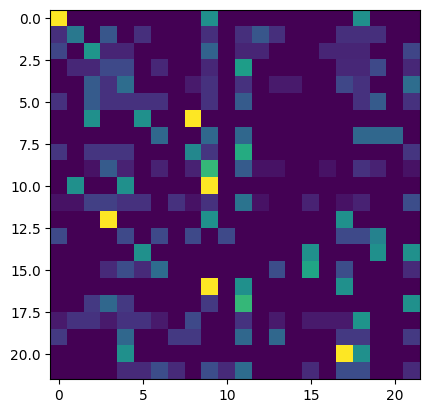

In [14]:
conf = sklearn.metrics.confusion_matrix(val_labellist, predList, normalize='true')
plt.imshow(conf)

In [15]:
per_class_acc = np.diag(conf)
print('mean accuracy: %.3f' % per_class_acc.mean())

mean accuracy: 0.122
